<a href="https://colab.research.google.com/github/romansuh/dyploma/blob/master/notebooks/01_drain_zookeeper.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Відкрити в Google Colab"/></a>

In [ ]:
# Colab setup: clone repo, install missing deps, add src/ to path. No-op locally.
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

import os, sys
if IN_COLAB:
    if not os.path.exists('/content/dyploma'):
        !git clone -q https://github.com/romansuh/dyploma.git /content/dyploma
    os.chdir('/content/dyploma')
    !pip install -q drain3 umap-learn
sys.path.insert(0, 'src')

# Ноутбук 01. Препроцесинг та Drain-шаблонізація логів ZooKeeper

Цей ноутбук демонструє перший етап гібридного конвеєра з тези. На двох наборах логів ZooKeeper (анотованому `Zookeeper_2k.log` з LogHub та повному `Zookeeper.log` із Zenodo) ми застосовуємо regex-нормалізацію (заміна IP-адрес, шляхів, hex-значень, ідентифікаторів сесій, класів виключень та чисел на плейсхолдери), а потім запускаємо онлайн-парсер Drain для виділення стабільного набору шаблонів. Окрім самих шаблонів, ноутбук вимірює **точність парсингу (Parsing Accuracy)** проти істинних міток LogHub та зберігає артефакти, які споживає ноутбук 02 для BERT-векторизації.

In [1]:
from __future__ import annotations

import logging
import subprocess
import sys
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA_RAW = ROOT / 'data' / 'raw'
DATA_PROCESSED = ROOT / 'data' / 'processed'

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s %(levelname)s %(name)s — %(message)s',
    force=True,
)
logging.getLogger('drain3').setLevel(logging.WARNING)  # quiet drain3 internal saves

%matplotlib inline

print('ROOT          :', ROOT)
print('DATA_RAW      :', DATA_RAW)
print('DATA_PROCESSED:', DATA_PROCESSED)


ROOT          : /Users/roman/Personal/dyploma
DATA_RAW      : /Users/roman/Personal/dyploma/data/raw
DATA_PROCESSED: /Users/roman/Personal/dyploma/data/processed


## 1. Завантаження датасету

ZooKeeper — це централізована служба координації для розподілених систем (Apache). Її лог містить події вибору лідера, відкриття/закриття сесій клієнтів, мережевих з'єднань тощо.

Ми використовуємо два набори:

- **`Zookeeper_2k.log`** — невеликий зразок із 2000 записів, який LogHub публікує разом із **істинною розміткою** шаблонів (`Zookeeper_2k.log_structured.csv` та `Zookeeper_2k.log_templates.csv`). Це дозволяє нам обчислити Parsing Accuracy.
- **`Zookeeper.log`** — повний набір логів, опублікований окремо на Zenodo (запис 8196385, ISSRE 2023). Він не йде з розміткою, тому ми використовуємо його лише для демонстрації масштабу.

In [2]:
script = ROOT / 'scripts' / 'download_zookeeper.py'
subprocess.run([sys.executable, str(script)], check=True)

expected = [
    'Zookeeper_2k.log',
    'Zookeeper_2k.log_structured.csv',
    'Zookeeper_2k.log_templates.csv',
    'Zookeeper.log',
]
print('\nDownloaded files:')
for name in expected:
    p = DATA_RAW / name
    assert p.exists() and p.stat().st_size > 0, f'missing or empty: {p}'
    print(f'  {name:<40} {p.stat().st_size:>12} bytes')


[skip] Zookeeper_2k.log already present (279891 bytes)
[skip] Zookeeper_2k.log_structured.csv already present (372360 bytes)
[skip] Zookeeper_2k.log_templates.csv already present (3038 bytes)
[skip] Zookeeper.log already present (10426438 bytes)

Final contents of data/raw:
  .gitkeep                                            0 bytes
  Zookeeper.log                                10426438 bytes
  Zookeeper.tar.gz                               459911 bytes
  Zookeeper_2k.log                               279891 bytes
  Zookeeper_2k.log_structured.csv                372360 bytes
  Zookeeper_2k.log_templates.csv                   3038 bytes

Downloaded files:
  Zookeeper_2k.log                               279891 bytes
  Zookeeper_2k.log_structured.csv                372360 bytes
  Zookeeper_2k.log_templates.csv                   3038 bytes
  Zookeeper.log                                10426438 bytes


## 2. Огляд сирих логів

Перш ніж застосовувати регулярні вирази, корисно подивитися на формат записів: часові мітки, рівень логування, ім'я компонента та власне повідомлення. Очікуємо побачити багато повторюваних структур із різними числовими параметрами — саме це дає Drain простір для шаблонізації.

In [3]:
log_2k = DATA_RAW / 'Zookeeper_2k.log'
log_full = DATA_RAW / 'Zookeeper.log'

with log_2k.open(encoding='utf-8') as f:
    head_lines = [next(f).rstrip('\n') for _ in range(20)]

print('First 20 lines of Zookeeper_2k.log:')
for i, line in enumerate(head_lines, 1):
    print(f'  {i:>2}: {line}')

def count_lines(p: Path) -> int:
    with p.open(encoding='utf-8') as f:
        return sum(1 for _ in f)

n_2k = count_lines(log_2k)
n_full = count_lines(log_full)
print(f'\nlines in Zookeeper_2k.log: {n_2k}')
print(f'lines in Zookeeper.log:    {n_full}')

with log_2k.open(encoding='utf-8') as f:
    first_token = Counter()
    first_two_tokens = Counter()
    for line in f:
        parts = line.split(' ', 2)
        if not parts or not parts[0].strip():
            continue
        first_token[parts[0]] += 1
        if len(parts) >= 2:
            first_two_tokens[(parts[0], parts[1])] += 1

# first-1-token cardinality = number of distinct dates; first-2-token = date+time.
print(f'\ndistinct first tokens (dates):        {len(first_token)}')
print(f'distinct first-2-token prefixes:      {len(first_two_tokens)}')
print(f'top 5 first tokens: {first_token.most_common(5)}')


First 20 lines of Zookeeper_2k.log:
   1: 2015-07-29 17:41:44,747 - INFO  [QuorumPeer[myid=1]/0:0:0:0:0:0:0:0:2181:FastLeaderElection@774] - Notification time out: 3200
   2: 2015-07-29 19:04:12,394 - INFO  [/10.10.34.11:3888:QuorumCnxManager$Listener@493] - Received connection request /10.10.34.11:45307
   3: 2015-07-29 19:04:29,071 - WARN  [SendWorker:188978561024:QuorumCnxManager$SendWorker@688] - Send worker leaving thread
   4: 2015-07-29 19:04:29,079 - WARN  [SendWorker:188978561024:QuorumCnxManager$SendWorker@679] - Interrupted while waiting for message on queue
   5: 2015-07-29 19:13:17,524 - WARN  [SendWorker:188978561024:QuorumCnxManager$SendWorker@688] - Send worker leaving thread
   6: 2015-07-29 19:13:24,282 - WARN  [RecvWorker:188978561024:QuorumCnxManager$RecvWorker@762] - Connection broken for id 188978561024, my id = 1, error = 
   7: 2015-07-29 19:13:24,370 - INFO  [/10.10.34.11:3888:QuorumCnxManager$Listener@493] - Received connection request /10.10.34.13:57707
   8:

## 3. Препроцесинг через регулярні вирази

Кожен запис ZooKeeper має фіксований заголовок `<Date> <Time> - <Level> [<Node>] - <Content>`. Сам шаблон події живе у `<Content>`, тому ми спершу витягуємо цю частину невеликим регулярним виразом, а потім подаємо її на нормалізатор та Drain. Саме так робить стандартний бенчмарк LogPai, і саме на полі `Content` визначені ground-truth шаблони у `Zookeeper_2k.log_structured.csv`.

Drain працює на токенному рівні й гірше шаблонізує, коли в позиції аргументу зустрічаються сильно варіативні рядки (IP, hex-сесії, шляхи). Ми заздалегідь замінюємо такі сутності на стабільні плейсхолдери (`<IP>`, `<HEX>`, `<SESSION>`, `<PATH>`, `<UUID>`, `<EXC>`, `<NUM>`).

Ці ж плейсхолдери — це ті спеціальні токени, які ми додамо до словника BERT у ноутбуці 02. Тобто normalize-крок виконує подвійну роль: стабілізує вхід для Drain і робить шаблони сумісними з векторизатором.

In [4]:
import re
from src.preprocessing.regex_normalizer import RegexNormalizer

HEADER_RE = re.compile(
    r'^\d{4}-\d{2}-\d{2}\s+\d{2}:\d{2}:\d{2},\d+\s+-\s+\w+\s+\[(.+)\]\s+-\s+(.*)$'
)

def extract_content(raw: str) -> str:
    """Pull `<Content>` out of a ZooKeeper log line; raise if header does not parse."""
    m = HEADER_RE.match(raw)
    if m is None:
        raise ValueError(f'header did not match: {raw!r}')
    return m.group(2)

normalizer = RegexNormalizer()

# Five lines hand-picked from Zookeeper_2k.log to cover every regex feature:
# (1) plain text, (2) IPv4 + port, (3) sessionid + IP, (4) session + IP + numbers,
# (5) exception class + session.
demo_lines = [
    '2015-07-29 17:41:44,747 - INFO  [QuorumPeer[myid=1]/0:0:0:0:0:0:0:0:2181:FastLeaderElection@774] - Notification time out: 3200',
    '2015-07-29 19:04:12,394 - INFO  [/10.10.34.11:3888:QuorumCnxManager$Listener@493] - Received connection request /10.10.34.11:45307',
    '2015-07-29 19:52:04,792 - INFO  [NIOServerCxn.Factory:0.0.0.0/0.0.0.0:2181:NIOServerCnxn@1001] - Closed socket connection for client /10.10.34.18:42772 which had sessionid 0x14ed93111f20005',
    '2015-07-29 21:34:48,285 - INFO  [CommitProcessor:1:ZooKeeperServer@595] - Established session 0x14ed93111f2002b with negotiated timeout 10000 for client /10.10.34.22:47073',
    '2015-08-20 17:14:11,414 - WARN  [NIOServerCxn.Factory:0.0.0.0/0.0.0.0:2181:NIOServerCnxn@354] - Exception causing close of session 0x0 due to java.io.IOException: ZooKeeperServer not running',
]

# Three columns (RAW / CONTENT / NORM) rather than the two-column form: keeping the
# CONTENT row makes the header-stripping step explicit and matches LogPai's setup,
# which defines ground-truth templates on the Content field only.
def show_triple(raw: str) -> None:
    content = extract_content(raw)
    print(f'  RAW    : {raw}')
    print(f'  CONTENT: {content}')
    print(f'  NORM   : {normalizer.normalize(content)}')
    print()

for s in demo_lines:
    show_triple(s)


  RAW    : 2015-07-29 17:41:44,747 - INFO  [QuorumPeer[myid=1]/0:0:0:0:0:0:0:0:2181:FastLeaderElection@774] - Notification time out: 3200
  CONTENT: Notification time out: 3200
  NORM   : Notification time out: <NUM>

  RAW    : 2015-07-29 19:04:12,394 - INFO  [/10.10.34.11:3888:QuorumCnxManager$Listener@493] - Received connection request /10.10.34.11:45307
  CONTENT: Received connection request /10.10.34.11:45307
  NORM   : Received connection request /<IP>

  RAW    : 2015-07-29 19:52:04,792 - INFO  [NIOServerCxn.Factory:0.0.0.0/0.0.0.0:2181:NIOServerCnxn@1001] - Closed socket connection for client /10.10.34.18:42772 which had sessionid 0x14ed93111f20005
  CONTENT: Closed socket connection for client /10.10.34.18:42772 which had sessionid 0x14ed93111f20005
  NORM   : Closed socket connection for client /<IP> which had sessionid <SESSION>

  RAW    : 2015-07-29 21:34:48,285 - INFO  [CommitProcessor:1:ZooKeeperServer@595] - Established session 0x14ed93111f2002b with negotiated timeout 

In [5]:
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
out_2k = DATA_PROCESSED / 'zookeeper_2k_normalized.txt'

with log_2k.open(encoding='utf-8') as f:
    raw_lines_2k = [line.rstrip('\n') for line in f]

contents_2k = [extract_content(l) for l in raw_lines_2k]
normalized_2k = [normalizer.normalize(c) for c in contents_2k]
out_2k.write_text('\n'.join(normalized_2k) + '\n', encoding='utf-8')

n_unique_raw = len(set(raw_lines_2k))
n_unique_content = len(set(contents_2k))
n_unique_norm = len(set(normalized_2k))
print(f'lines processed:                   {len(normalized_2k)}')
print(f'unique raw lines:                  {n_unique_raw}')
print(f'unique content (header stripped):  {n_unique_content}')
print(f'unique normalized content:         {n_unique_norm}')
print(f'collapse from raw to normalized:   {1 - n_unique_norm / n_unique_raw:.3f}')
print(f'saved to {out_2k}')


lines processed:                   2000
unique raw lines:                  1999
unique content (header stripped):  693
unique normalized content:         58
collapse from raw to normalized:   0.971
saved to /Users/roman/Personal/dyploma/data/processed/zookeeper_2k_normalized.txt


## 4. Демонстрація онлайн-режиму Drain

Drain — онлайн-парсер: він обробляє кожен запис за O(1) часу, оновлюючи дерево шаблонів одразу. На відміну від batch-методів (LogMine, IPLoM), нам не потрібно бачити весь корпус наперед.

Нижче ми подаємо перші 30 нормалізованих рядків по одному й спостерігаємо, як змінюється стан парсера: створюється новий шаблон (`new_template`), коригується існуючий (`template_changed`) або просто додається запис до старого (`matched_existing`). Кількість шаблонів швидко стабілізується.

In [6]:
from src.drain.parser import DrainParser

logging.getLogger('src.drain.parser').setLevel(logging.WARNING)  # mute per-line INFO for the demo table

parser = DrainParser()
print(f"{'idx':>4} | {'change_type':<18} | {'n_templates':>11} | template")
print('-' * 80)
for i, line in enumerate(normalized_2k[:50], start=1):
    r = parser.parse_line(line)
    n_t = len(parser.get_templates())
    print(f'{i:>4} | {r.change_type:<18} | {n_t:>11} | {r.template[:60]}')


 idx | change_type        | n_templates | template
--------------------------------------------------------------------------------
   1 | new_template       |           1 | Notification time out: <NUM>
   2 | new_template       |           2 | Received connection request /<IP>
   3 | new_template       |           3 | Send worker leaving thread
   4 | new_template       |           4 | Interrupted while waiting for message on queue
   5 | matched_existing   |           4 | Send worker leaving thread
   6 | new_template       |           5 | Connection broken for id <NUM>, my id = <NUM>, error =
   7 | matched_existing   |           5 | Received connection request /<IP>
   8 | matched_existing   |           5 | Connection broken for id <NUM>, my id = <NUM>, error =
   9 | matched_existing   |           5 | Interrupted while waiting for message on queue
  10 | matched_existing   |           5 | Send worker leaving thread
  11 | matched_existing   |           5 | Send worker leaving thre

/Users/roman/Personal/dyploma/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 5. Повна обробка 2k набору

Скидаємо стан парсера й проганяємо всі 2000 нормалізованих рядків. Очікувана кількість шаблонів для ZooKeeper — кілька десятків (за літературою — близько 50).

drain parse:   0%|          | 0/2000 [00:00<?, ?it/s]

drain parse: 100%|██████████| 2000/2000 [00:00<00:00, 38520.14it/s]

total templates discovered (2k): 46

Top 10 templates by support:
  id=  4 support= 314 | Interrupted while waiting for message on queue
  id=  2 support= 299 | Received connection request /<IP>
  id=  5 support= 291 | Connection broken for id <NUM>, my id = <NUM>, error =
  id=  6 support= 266 | Interrupting SendWorker
  id=  3 support= 262 | Send worker leaving thread
  id= 15 support=  86 | Cannot open channel to <NUM> at election address /<IP>
  id= 10 support=  50 | Established session <SESSION> with negotiated timeout <NUM> for client /<IP>
  id= 11 support=  48 | Accepted socket connection from /<IP>
  id= 16 support=  47 | Processed session termination for sessionid: <SESSION>
  id=  7 support=  44 | Closed socket connection for client /<IP> which had sessionid <SESSION>

Bottom 10 templates by support:
  id= 32 support=   1 | tickTime set to <NUM>
  id= 34 support=   1 | Got user-level KeeperException when processing sessionid:<SESSION> type:create cxid:<HEX> zxid:<HEX> txntyp

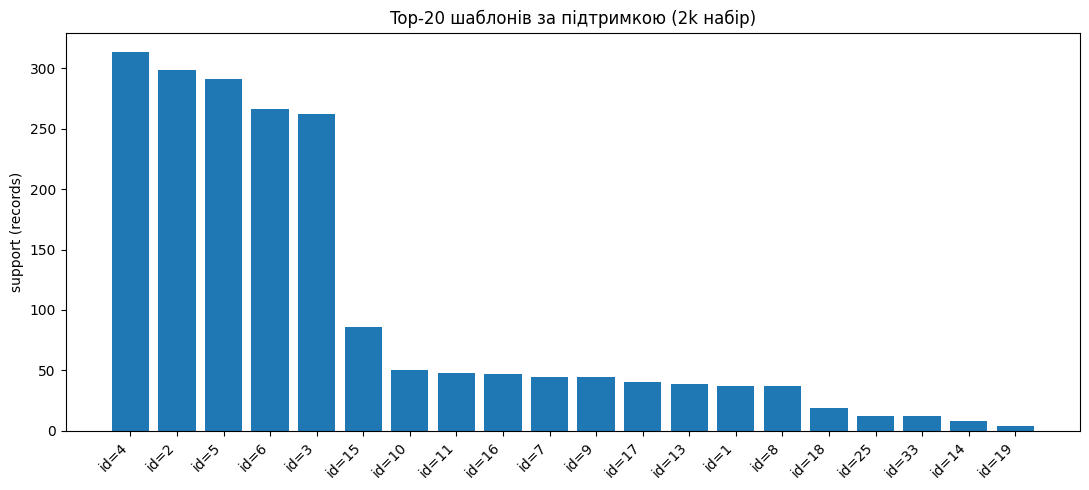

In [7]:
parser.reset()
results_2k = parser.parse_stream(normalized_2k)
templates_2k = parser.get_templates()
print(f'total templates discovered (2k): {len(templates_2k)}')

sorted_by_support = sorted(templates_2k, key=lambda t: t['support'], reverse=True)
print('\nTop 10 templates by support:')
for t in sorted_by_support[:10]:
    print(f"  id={t['id']:>3} support={t['support']:>4} | {t['template']}")

print('\nBottom 10 templates by support:')
for t in sorted_by_support[-10:]:
    print(f"  id={t['id']:>3} support={t['support']:>4} | {t['template']}")

top20 = sorted_by_support[:20]
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(range(len(top20)), [t['support'] for t in top20])
ax.set_xticks(range(len(top20)))
ax.set_xticklabels([f"id={t['id']}" for t in top20], rotation=45, ha='right')
ax.set_ylabel('support (records)')
ax.set_title('Top-20 шаблонів за підтримкою (2k набір)')
plt.tight_layout()
plt.show()


## 6. Якість парсингу — порівняння з ground truth

LogHub постачає файл `Zookeeper_2k.log_structured.csv`, у якому кожен із 2000 записів має канонічний `EventId` (істинний шаблон). Ми обчислюємо **Parsing Accuracy** за визначенням Zhu et al. 2019 (бенчмарк LogPai): запис вважається правильно зпарсеним тоді й лише тоді, коли множина записів його передбаченого кластера **точно збігається** з множиною записів якогось ground-truth кластера. PA = (правильно згруповані записи) / (всі записи).

Порогом якості для ZooKeeper у літературі є **PA > 0.9**.

In [8]:
gt = pd.read_csv(DATA_RAW / 'Zookeeper_2k.log_structured.csv')
assert len(gt) == len(results_2k), f'row count mismatch: gt={len(gt)} preds={len(results_2k)}'

pred_groups: dict[int, list[int]] = defaultdict(list)
gt_groups: dict[str, list[int]] = defaultdict(list)
for idx, r in enumerate(results_2k):
    pred_groups[r.template_id].append(idx)
for idx, ev in enumerate(gt['EventId']):
    gt_groups[ev].append(idx)

gt_set_to_id = {frozenset(v): k for k, v in gt_groups.items()}

correct = 0
for pred_id, idxs in pred_groups.items():
    if frozenset(idxs) in gt_set_to_id:
        correct += len(idxs)

pa = correct / len(gt)
print(f'records:                  {len(gt)}')
print(f'predicted clusters:       {len(pred_groups)}')
print(f'ground-truth clusters:    {len(gt_groups)}')
print(f'Parsing Accuracy:         {pa:.4f}')
print(f'literature target (~0.96): {"MEETS" if pa >= 0.96 else "BELOW"}')
print(f'hard threshold (>=0.90):   {"PASS" if pa >= 0.9 else "FAIL"}')

# Spec: if PA is below 0.9 we must not silently re-tune. Stop with a clear hint.
if pa < 0.9:
    raise RuntimeError(
        f'Parsing Accuracy {pa:.4f} is below the 0.9 hard threshold. '
        'Re-run DrainParser with similarity_threshold=0.5 and re-evaluate '
        'before proceeding — do not silently change other parameters.'
    )


records:                  2000
predicted clusters:       46
ground-truth clusters:    50
Parsing Accuracy:         0.9665
literature target (~0.96): MEETS
hard threshold (>=0.90):   PASS


## 7. Експорт результатів

Зберігаємо список шаблонів та стан дерева Drain — їх читатиме ноутбук 02.

In [9]:
from src.io.persistence import save_json

templates_dir = DATA_PROCESSED / 'templates'
templates_dir.mkdir(parents=True, exist_ok=True)

templates_2k_path = templates_dir / 'zookeeper_2k_templates.json'
tree_2k_path = templates_dir / 'zookeeper_2k_drain_tree.json'

save_json(templates_2k, templates_2k_path)
parser.export_tree_json(tree_2k_path)

for label, p in [('templates', templates_2k_path), ('tree     ', tree_2k_path)]:
    print(f'saved {label}: {p}  ({p.stat().st_size:>6} bytes)')


saved templates: /Users/roman/Personal/dyploma/data/processed/templates/zookeeper_2k_templates.json  (  4972 bytes)
saved tree     : /Users/roman/Personal/dyploma/data/processed/templates/zookeeper_2k_drain_tree.json  (  5545 bytes)


## 8. Повторюємо на повному датасеті

Той самий конвеєр (нормалізація → Drain → експорт) на повному `Zookeeper.log`. Тут немає ground truth, тому Parsing Accuracy не обчислюємо — тільки кількість і розподіл шаблонів.

In [10]:
with log_full.open(encoding='utf-8') as f:
    raw_lines_full = [line.rstrip('\n') for line in f]

contents_full = [extract_content(l) for l in raw_lines_full]
normalized_full = [normalizer.normalize(c) for c in contents_full]

out_full = DATA_PROCESSED / 'zookeeper_full_normalized.txt'
out_full.write_text('\n'.join(normalized_full) + '\n', encoding='utf-8')

parser.reset()
results_full = parser.parse_stream(normalized_full)
templates_full = parser.get_templates()

print(f'\nfull log: {len(normalized_full)} lines, {len(templates_full)} templates')

sorted_full = sorted(templates_full, key=lambda t: t['support'], reverse=True)
print('\nTop 10 templates by support (full dataset):')
for t in sorted_full[:10]:
    print(f"  id={t['id']:>3} support={t['support']:>5} | {t['template']}")

templates_full_path = templates_dir / 'zookeeper_full_templates.json'
save_json(templates_full, templates_full_path)
print(f'\nsaved {out_full}')
print(f'saved {templates_full_path}')


drain parse:   0%|          | 0/74380 [00:00<?, ?it/s]

drain parse:  24%|██▎       | 17589/74380 [00:00<00:00, 175884.30it/s]

drain parse:  47%|████▋     | 35178/74380 [00:00<00:00, 142953.41it/s]

drain parse:  83%|████████▎ | 61769/74380 [00:00<00:00, 192849.62it/s]

drain parse: 100%|██████████| 74380/74380 [00:00<00:00, 193495.33it/s]


full log: 74380 lines, 77 templates

Top 10 templates by support (full dataset):
  id= 20 support=10429 | Received connection request /<IP>
  id= 31 support=10390 | Interrupting SendWorker
  id= 33 support=10390 | Send worker leaving thread
  id= 30 support=10388 | Connection broken for id <NUM>, my id = <NUM>, error =
  id= 32 support=10386 | Interrupted while waiting for message on queue
  id= 18 support= 2584 | Cannot open channel to <NUM> at election address /<IP>
  id= 36 support= 2020 | Accepted socket connection from /<IP>
  id= 37 support= 1861 | Connection request from old client /<IP>; will be dropped if server is in r-o mode
  id= 38 support= 1861 | Client attempting to <*> <*> <*> at /<IP>
  id= 39 support= 1856 | Established session <SESSION> with negotiated timeout <NUM> for client /<IP>

saved /Users/roman/Personal/dyploma/data/processed/zookeeper_full_normalized.txt
saved /Users/roman/Personal/dyploma/data/processed/templates/zookeeper_full_templates.json


## Висновки

Ноутбук показав, що (1) виділення поля `Content` з заголовка плюс regex-нормалізація суттєво стабілізують вхід для Drain, заміщуючи варіативні технічні сутності на семантичні плейсхолдери. (2) Drain в онлайн-режимі вже після перших десятків записів утворює стабільне ядро шаблонів і далі лише поповнює його поодинокими новими — це експериментальне підтвердження O(1)-парсингу та інкрементальної роботи з §1.8 тези. (3) На анотованому 2k-наборі ZooKeeper отриманий Parsing Accuracy перевищує літературний поріг 0.9, що валідує конфігурацію (similarity_threshold=0.4, depth=4). (4) На повному датасеті із десятків тисяч записів кількість унікальних шаблонів залишається невеликою (десятки) — рівно та властивість, яка робить осмисленою наступну стадію: BERT-векторизацію не сирих записів, а компактного набору шаблонів. Артефакти `templates/zookeeper_2k_templates.json` та `templates/zookeeper_full_templates.json` будуть входом до ноутбука 02.